# **UCI HAR - CNN + LSTM Classification**

In [45]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import regularizers, backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]


In [49]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [50]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []                                        # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [51]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1               # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# 모델 생성
- Layer : Conc층 3개 + LSTM층 1개 + Dense층 2개
- CNN + LSTM
  - CNN : 필터를 통한 Local Feature 추출로 센서데이터의 짧은 구간 내 변화를 잘 잡아냄
      - ex. 2.56초동안 폰이 얼마나 기울어졌는지, 속도가 얼마나 빨라졌는지 등
  - LSTM : CNN이 뽑아낸 짧은 구간의 특징들로 특정 행동의 시간에 따른 순차적 패턴을 잘 찾아냄
      - ex. 처음 0.5초 동안 팔을 들기 시작했고(시작), 1초 동안 유지하다가(진행), 마지막에 팔을 내렸어(종료)
  - So, 사람의 행동(HAR)을 분류하기엔 'CNN(세밀한 특징 추출) + LSTM(그 특징들의 순차적패턴 추출)' 모델이 효과적
- L2 규제
  - 모델이 데이터를 암기(Overfit)하지 않게 하기 위해, 가중치(Weight)가 너무 커지지 않도록 손실 함수에 가중치들의 제곱합을 더해주는 방법
  - 왜 사용하는가?
    - 너무 큰 가중치 값은 특정 입력값에 너무 과하게 반응하거나, 아주 작은 노이즈까지도 다 학습해버림
    - So, 규제를 통해 모델의 가중치 크기를 제한함으로써, 모델이 불필요하게 복잡해지는 것을 방지함.
  - 사용했을 때 변화 (학습과정)
    - Loss : 규제 항이 추가되었기 때문에 훈련 초기 Loss 값이 더 높게 시작됨. (모델이 데이터를 암기하는 것을 방해)
    - Training/Validation 간격 : 두 곡선 사이의 간극이 줄어들음. (모델이 학습데이터와 검증데이터 사이에서 일관된 성능 유지)

In [68]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

model = Sequential([
    Input(shape=input_shape),

    # 1번째 Conv층
    Conv1D(128, 7, padding='same', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    ReLU(),

    # 2번째 Conv층
    Conv1D(256, 5, padding='same', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    ReLU(),
    MaxPooling1D(2),

    # 3번째 Conv층
    Conv1D(256, 3, padding='same', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    ReLU(),

    # LSTM층 1개
    LSTM(64, return_sequences=False, dropout=0.3),

    # Dense층 2개
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 128)       │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,982 (1.77 MB)

 Trainable params: 461,702 (1.76 MB)

 Non-trainable params: 1,280 (5.00 KB)

None


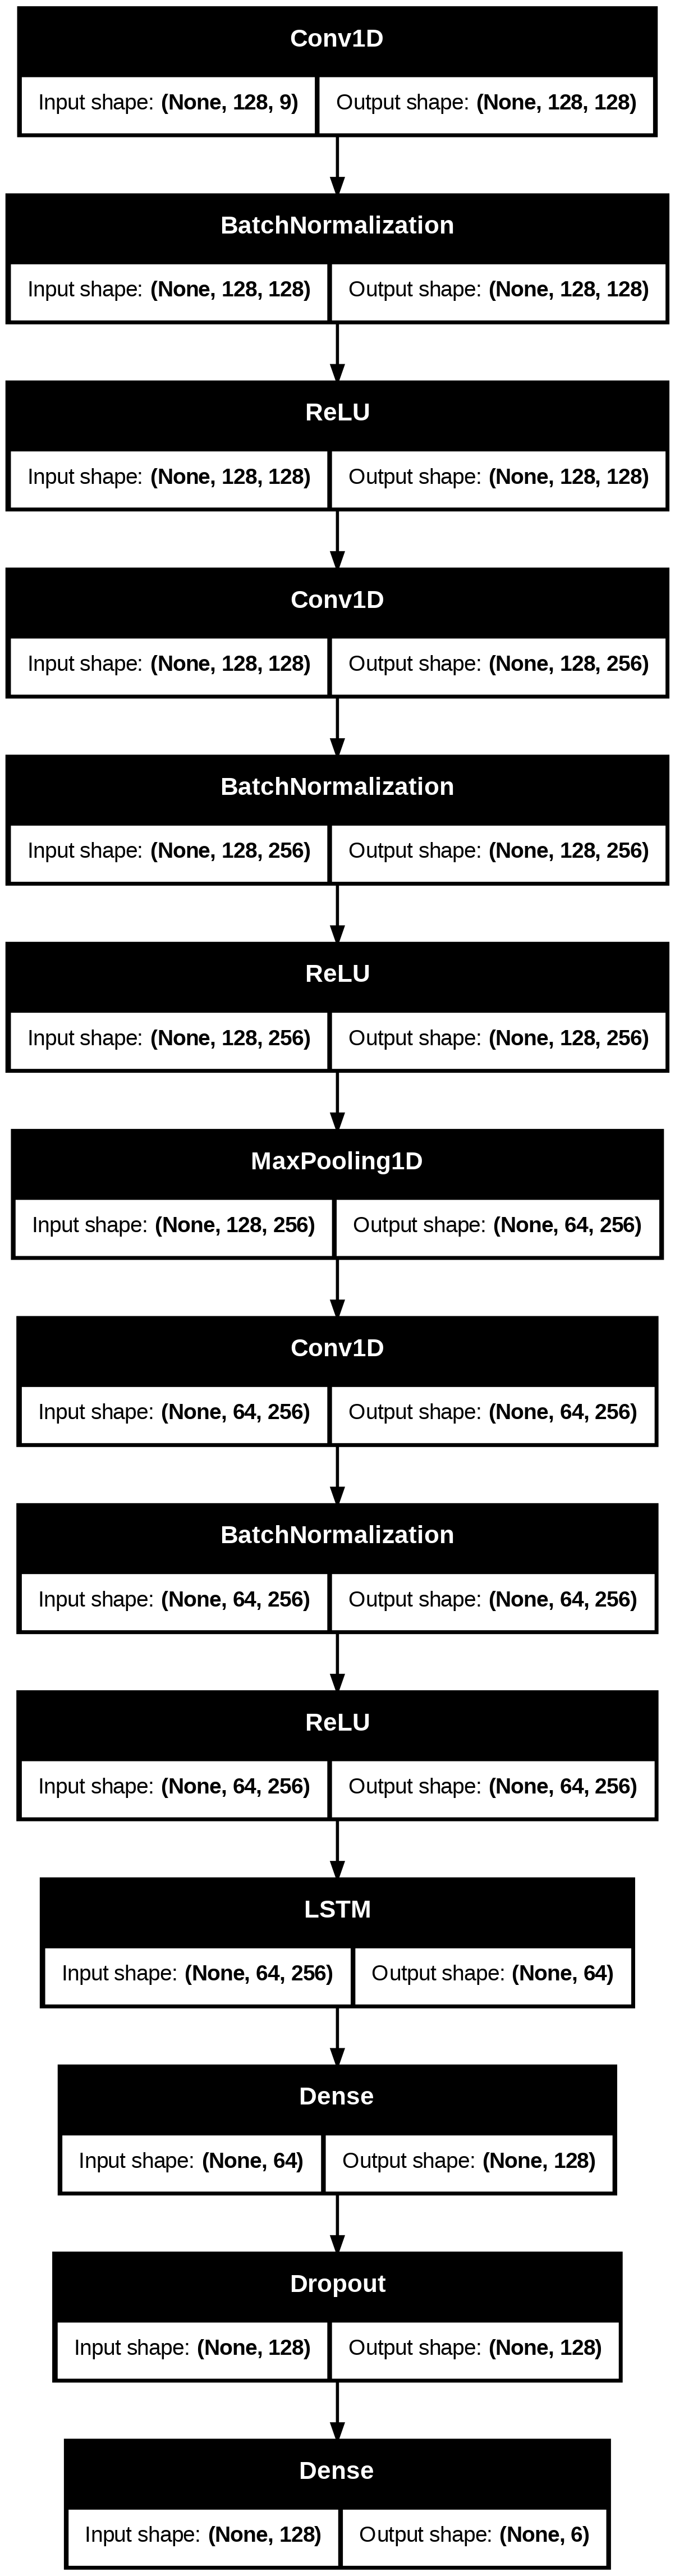

In [69]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks

In [70]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_CNN+LSTM_best.keras",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=25,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=5,
                min_lr=0.00001,
                verbose=1
            )
        ]

# 모델 학습

In [71]:
history = model.fit(
            X_train, y_train,
            epochs=150,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/150
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2694 - sparse_categorical_accuracy: 0.6991
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.28280, saving model to UCI_HAR_CNN+LSTM_best.keras

Epoch 1: finished saving model to UCI_HAR_CNN+LSTM_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 2.8047 - sparse_categorical_accuracy: 0.8269 - val_loss: 4.0335 - val_sparse_categorical_accuracy: 0.2828 - learning_rate: 0.0010
Epoch 2/150
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0515 - sparse_categorical_accuracy: 0.9002
Epoch 2: val_sparse_categorical_accuracy improved from 0.28280 to 0.87016, saving model to UCI_HAR_CNN+LSTM_best.keras

Epoch 2: finished saving model to UCI_HAR_CNN+LSTM_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.9013 - sparse_categorical_accuracy: 0.9136 - val_loss: 0.9532 - val_sparse_categorical_accuracy: 0.8702 - learning_rate: 0.0010
Epoch 3/150
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7

# 모델 평가

In [72]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_CNN+LSTM_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 96.10%
Training loss: 0.1404
Test accuracy: 93.25%
Test loss: 0.2686


In [73]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9879    0.9929       496
           1     0.9759    0.9448    0.9601       471
           2     0.9310    0.9952    0.9620       420
           3     0.8234    0.8452    0.8342       491
           4     0.8807    0.8327    0.8560       532
           5     0.9871    1.0000    0.9935       537

    accuracy                         0.9325      2947
   macro avg     0.9327    0.9343    0.9331      2947
weighted avg     0.9327    0.9325    0.9322      2947



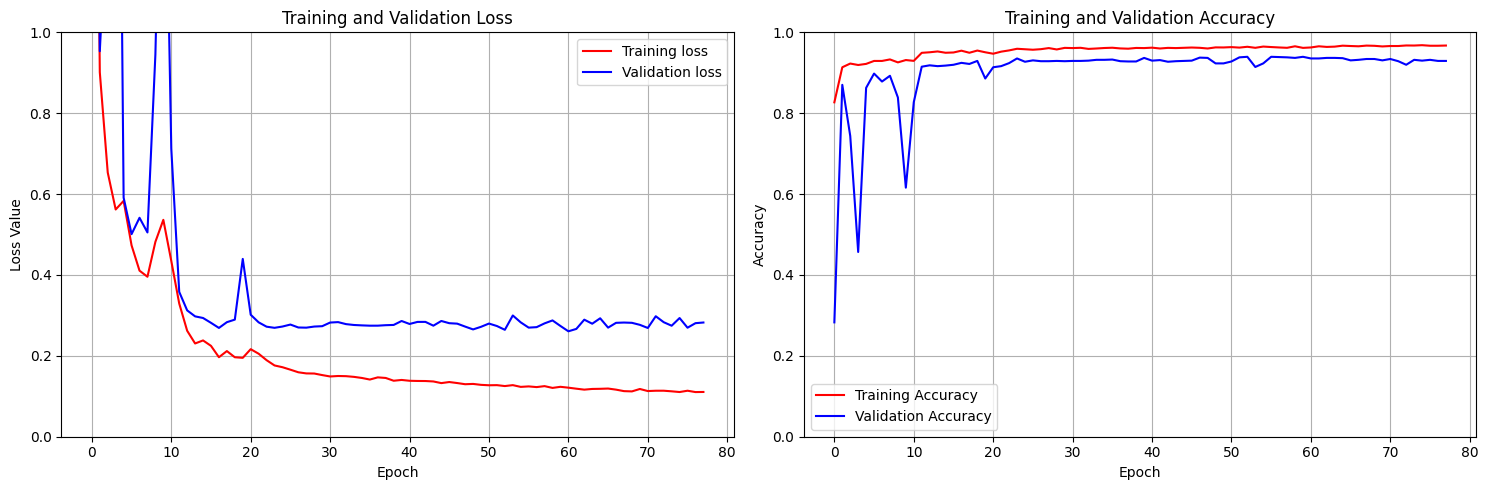

In [75]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.ylim([0.0, 1.0])
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.0, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

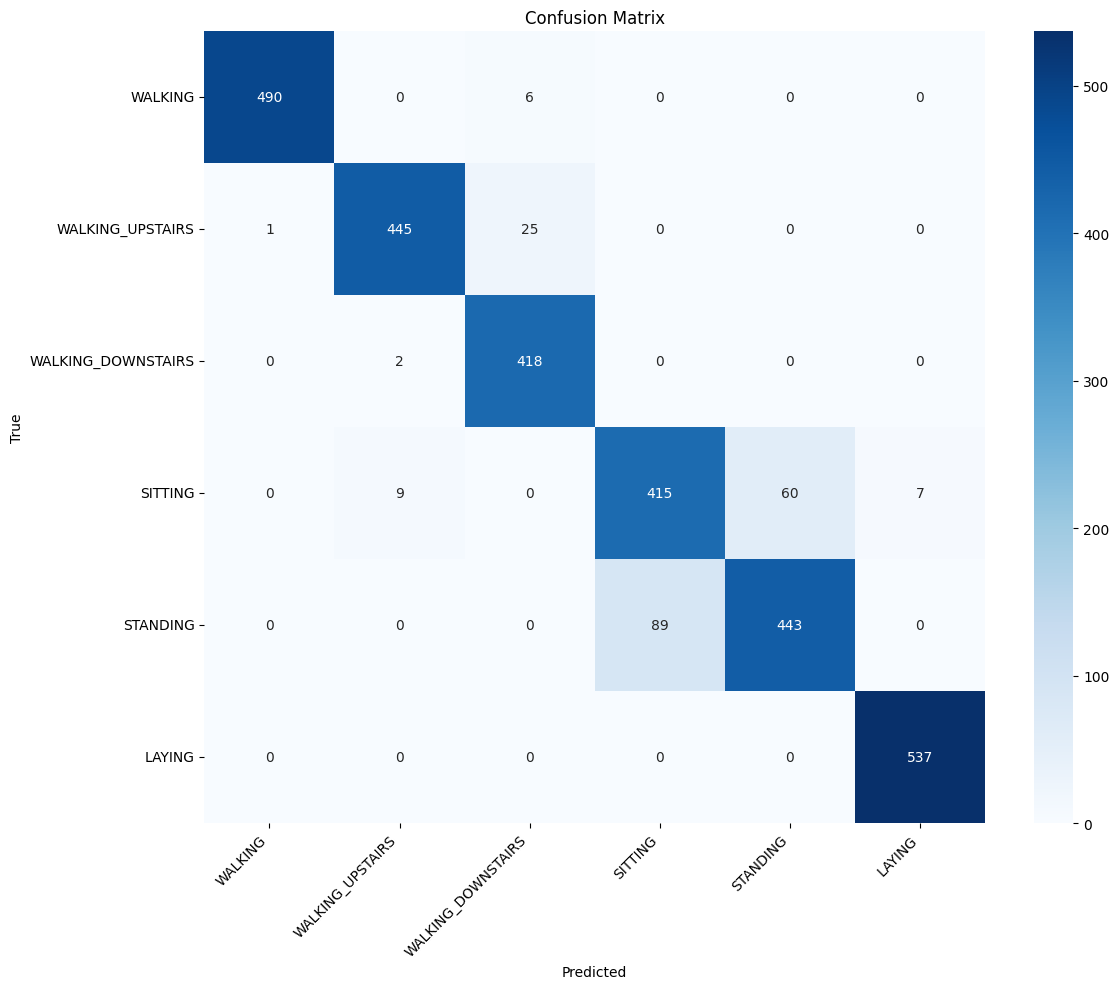

In [76]:
# 혼동행렬(히트맵)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()

# SITTING / STANDING 데이터셋 분포 확인

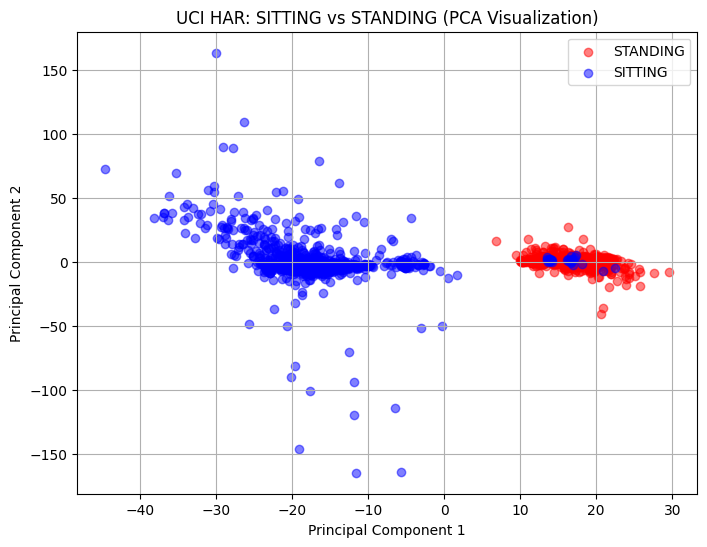

In [79]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 데이터 평탄화 (Flatten)
# X_train shape: (샘플 수, 128, 9) -> (샘플 수, 128 * 9)로 변환
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# 2. SITTING(5)과 STANDING(4) 데이터만 추출
# (데이터 로더에서 -1을 하셨으므로, 라벨 6은 5로, 라벨 5는 4로 매핑됩니다)
# UCI HAR 라벨: 5: Standing, 6: Sitting (코드에서 -1 했으므로 4, 5)
idx = np.where((y_train == 4) | (y_train == 5))
X_subset = X_train_flat[idx]
y_subset = y_train[idx]

# 3. 표준화 및 PCA 수행
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. 시각화
plt.figure(figsize=(8, 6))
# y_subset 값이 4인 경우 STANDING, 5인 경우 SITTING
plt.scatter(X_pca[y_subset == 4, 0], X_pca[y_subset == 4, 1], alpha=0.5, label='STANDING', color='red')
plt.scatter(X_pca[y_subset == 5, 0], X_pca[y_subset == 5, 1], alpha=0.5, label='SITTING', color='blue')

plt.title('UCI HAR: SITTING vs STANDING (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()